# Notebook 2 — Exploratory Data Analysis & Distributed Profiling
This notebook demonstrates PySpark SQL queries, statistical profiling (mean, median, std, skewness, kurtosis), quality assessment, and visualization.

In [23]:
# SECTION 1 — Load & Verify Distributed Parquet Data
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import *

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = (
    SparkSession.builder
    .appName("Bus Service Benchmarking - EDA")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.driver.memory", "6g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

df = spark.read.parquet("output/benchmark_dataset").cache()
num_records = df.count()
print(f"Successfully loaded {num_records} Trip Records for EDA.")
print(f"Partition Count: {df.rdd.getNumPartitions()}")
print("Master:", spark.sparkContext.master)
print("Default Parallelism:", spark.sparkContext.defaultParallelism)

Successfully loaded 19304 Trip Records for EDA.
Partition Count: 1
Master: local[*]
Default Parallelism: 16


In [24]:
target_cols = ["Trips", "Stops", "RouteAvgSpeed", "RouteMaxSpeed", "RouteDisruptions", "ServicePerformanceIndex"]

for col_name in target_cols:
    print(f"\n--- Statistical Metrics for: {col_name} ---")
    df.select(
        mean(col_name).alias(f"Mean_{col_name}"),
        expr(f"percentile_approx({col_name}, 0.5)").alias(f"Median_{col_name}"),
        stddev(col_name).alias(f"Std_{col_name}"),
        skewness(col_name).alias(f"Skew_{col_name}"),
        kurtosis(col_name).alias(f"Kurtosis_{col_name}")
    ).show()


--- Statistical Metrics for: Trips ---
+----------------+------------+------------------+-----------------+------------------+
|      Mean_Trips|Median_Trips|         Std_Trips|       Skew_Trips|    Kurtosis_Trips|
+----------------+------------+------------------+-----------------+------------------+
|51.4723891421467|          15|105.86165994903155|5.152960527586855|42.268190154484394|
+----------------+------------+------------------+-----------------+------------------+


--- Statistical Metrics for: Stops ---
+-----------------+------------+-----------------+------------------+-----------------+
|       Mean_Stops|Median_Stops|        Std_Stops|        Skew_Stops|   Kurtosis_Stops|
+-----------------+------------+-----------------+------------------+-----------------+
|83.02300041442189|          71|73.54508720670222|10.950966871768514|259.0559247639412|
+-----------------+------------+-----------------+------------------+-----------------+


--- Statistical Metrics for: RouteAvg

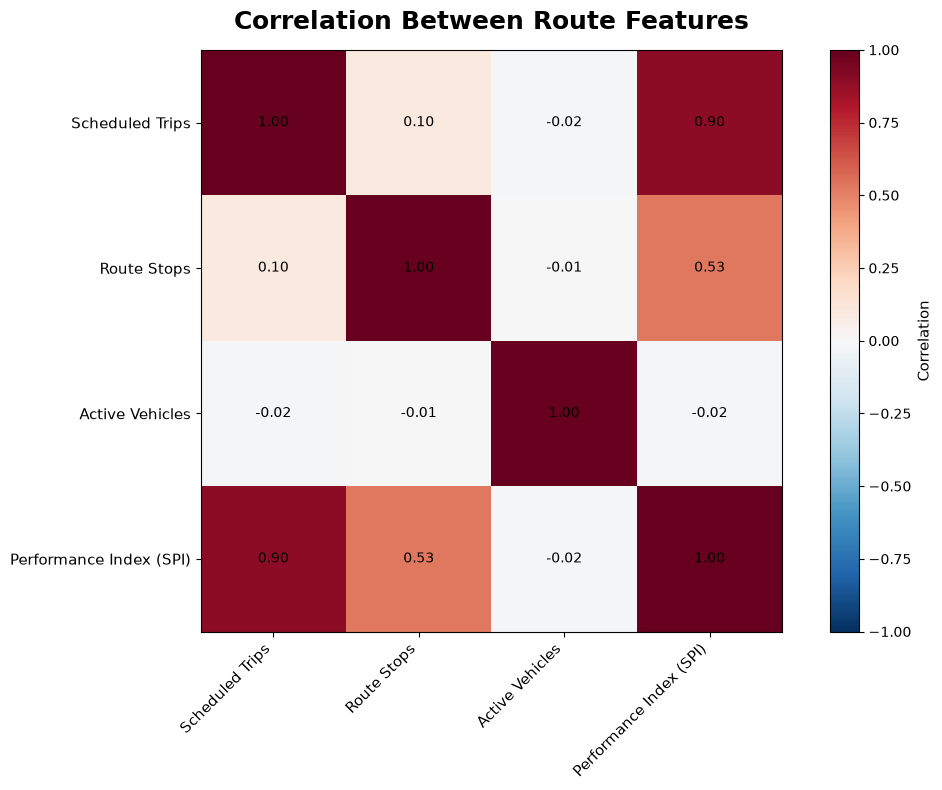

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Create Spark SQL view
df.createOrReplaceTempView("trips")

# Load only the variables used in the figure
route_metrics = spark.sql("""
SELECT
    Trips AS `Scheduled Trips`,
    Stops AS `Route Stops`,
    RouteVehicleCount AS `Active Vehicles`,
    ServicePerformanceIndex AS `Performance Index (SPI)`
FROM trips
""").fillna(0.0)

# Convert to Pandas
pdf = route_metrics.toPandas()

# Remove any constant columns (optional but recommended)
pdf = pdf.loc[:, pdf.nunique() > 1]

# Compute Pearson correlation matrix
corr = pdf.corr()

# Plot
fig, ax = plt.subplots(figsize=(11, 8))

im = ax.imshow(
    corr,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

# Tick locations
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))

# Tick labels
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(corr.columns, fontsize=11)

# Correlation values
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            color="black"
        )

# Color bar
cbar = plt.colorbar(im)
cbar.set_label("Correlation", fontsize=11)

# Title
plt.title(
    "Correlation Between Route Features",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

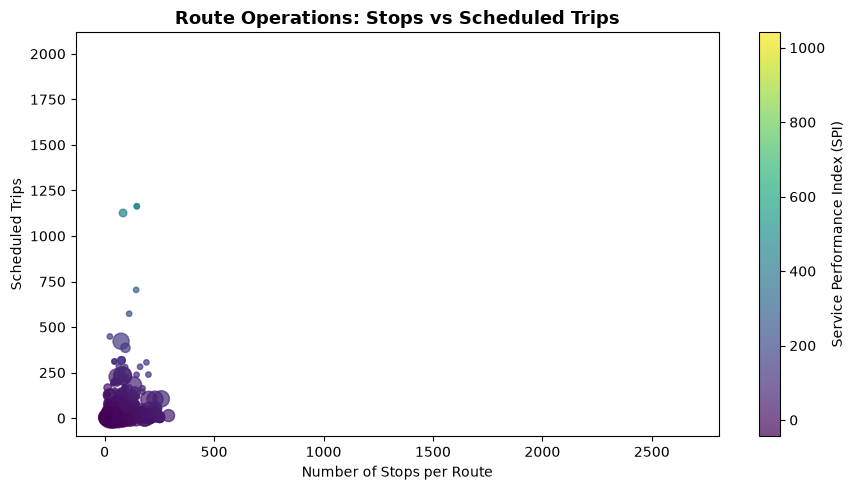

In [26]:
plt.figure(figsize=(9,5))

scatter = plt.scatter(
    x=pdf["Route Stops"],
    y=pdf["Scheduled Trips"],
    c=pdf["Performance Index (SPI)"],
    cmap="viridis",
    alpha=0.7,
    s=pdf["Active Vehicles"] * 15
)

cbar = plt.colorbar(scatter)
cbar.set_label("Service Performance Index (SPI)")

plt.title(
    "Route Operations: Stops vs Scheduled Trips",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Number of Stops per Route")
plt.ylabel("Scheduled Trips")

plt.tight_layout()
plt.show()

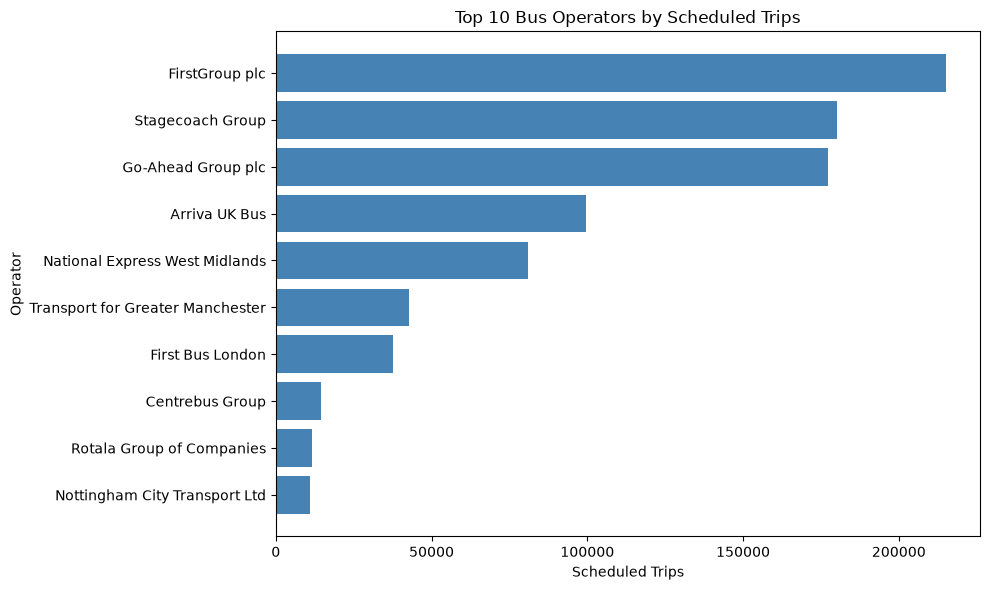

In [27]:
import matplotlib.pyplot as plt

operator_df = spark.sql("""
SELECT
    Operator,
    SUM(Trips) AS TotalTrips
FROM trips
GROUP BY Operator
ORDER BY TotalTrips DESC
LIMIT 10
""").toPandas()

plt.figure(figsize=(10,6))

plt.barh(
    operator_df["Operator"],
    operator_df["TotalTrips"],
    color="steelblue"
)

plt.gca().invert_yaxis()

plt.xlabel("Scheduled Trips")
plt.ylabel("Operator")
plt.title("Top 10 Bus Operators by Scheduled Trips")

plt.tight_layout()
plt.show()

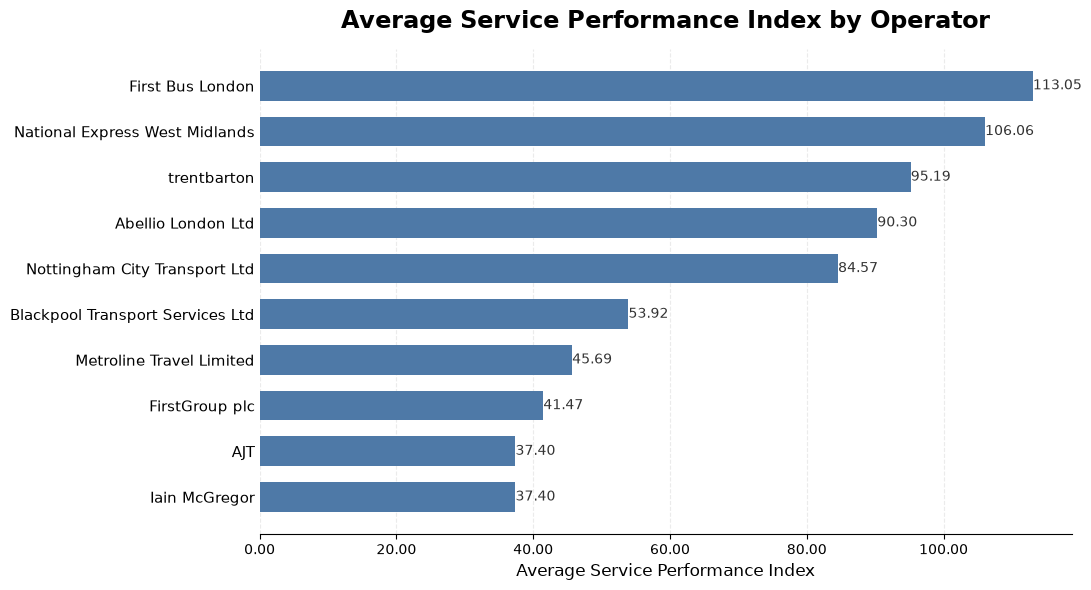

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Load data
df = spark.sql("""
SELECT
    Operator,
    AVG(ServicePerformanceIndex) AS AvgSPI
FROM trips
GROUP BY Operator
ORDER BY AvgSPI DESC
""").toPandas()

# Keep only the top 10 operators
df = df.head(10)

fig, ax = plt.subplots(figsize=(11, 6))

# Professional color
bars = ax.barh(
    df["Operator"],
    df["AvgSPI"],
    color="#4E79A7",
    edgecolor="none",
    height=0.65
)

# Highest value at the top
ax.invert_yaxis()

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center",
        fontsize=10,
        color="#333333"
    )

# Titles and labels
ax.set_title(
    "Average Service Performance Index by Operator",
    fontsize=17,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Average Service Performance Index", fontsize=12)
ax.set_ylabel("")

# Light gridlines
ax.xaxis.grid(True, linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Improve tick appearance
ax.tick_params(axis="y", labelsize=11, length=0)
ax.tick_params(axis="x", labelsize=10)

# Optional: format x-axis to two decimals
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))

plt.tight_layout()
plt.show()